## Part 2
### In this part, We are going to use the smart_sensors.csv file for this exercise. The file represents the entire dataset related to Smart Homes from Kaggle. Link to data set: https://www.kaggle.com/datasets/pythonafroz/smart-home-data-set . We will apply pandas functions for cleaning and visualization.


In [2]:
import pandas as pd
# Load the dataset with low_memory=False
df = pd.read_csv('smart_sensors.csv', low_memory=False)

# Check the first few rows
df.head()

,id,temp,humid,bright,dist,soundthres,soundlevel,pir,result_time,nodeid
0,2603,31.2,31,3.14005,176.868,0,0.317742,1,2020-09-20 00:00:01.901248,13
1,2604,31.2,30,3.14005,203.879,0,0.188972,0,2020-09-20 00:00:11.931381,13
2,2605,31.2,30,3.14005,177.674,0,1.585270,0,2020-09-20 00:00:21.86012,13
3,2606,31.2,31,3.14005,202.970,0,0.507504,0,2020-09-20 00:00:31.896596,13
4,2607,31.2,31,3.14005,-1.000,0,0.045204,0,2020-09-20 00:00:41.933249,13


In [3]:
# Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606210 entries, 0 to 606209
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           606210 non-null  int64  
 1   temp         606210 non-null  object 
 2   humid        606210 non-null  object 
 3   bright       606210 non-null  float64
 4   dist         606210 non-null  float64
 5   soundthres   606210 non-null  int64  
 6   soundlevel   606210 non-null  float64
 7   pir          606210 non-null  int64  
 8   result_time  606210 non-null  object 
 9   nodeid       606210 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 46.3+ MB


#### Data Cleaning
#### Objective: Clean and prepare the dataset for analysis.

1. Convert temp and humid to numeric values.
2. Remove invalid rows (e.g., negative distance values).
3. Fill missing values with meaningful substitutes (e.g., column means).


In [4]:
# apply the code in slide 27 and check the results
# Convert temp and humid to numeric, replacing invalid values with NaN
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['humid'] = pd.to_numeric(df['humid'], errors='coerce')

# Remove invalid distance readings
df = df[df['dist'] > 0].copy()

# print the number of missing values
df.isna().any()


id             False
temp            True
humid           True
bright         False
dist           False
soundthres     False
soundlevel     False
pir            False
result_time    False
nodeid         False
dtype: bool

In [5]:
# Fill missing humidity values with the mean
df['humid'] = df['humid'].fillna(df['humid'].mean())
df['temp'] = df['temp'].fillna(df['temp'].mean())

# Verify the cleaned data
df.isna().any().sum()


0

#### Exploring DataFrames (Activity Slide 28)


In [6]:
# Show statistics 
df.describe()

,id,temp,humid,bright,dist,soundthres,soundlevel,pir,nodeid
count,411961.000000,411961.000000,411961.000000,411961.000000,411961.000000,411961.000000,411961.000000,411961.000000,411961.0
mean,320066.832863,28.034534,46.934048,2.097319,174.400129,0.412787,0.823555,0.082129,13.0
std,197439.252803,2.388295,7.261079,1.169363,89.987617,0.492336,0.586398,0.274562,0.0
min,2603.000000,10.000000,10.000000,0.147405,3.292800,0.000000,0.000000,0.000000,13.0
25%,119039.000000,26.200000,42.000000,0.823404,97.171900,0.000000,0.232758,0.000000,13.0
50%,340414.000000,28.800000,47.000000,2.897420,175.805000,0.000000,0.961638,0.000000,13.0
75%,503776.000000,29.900000,53.000000,3.140050,263.115000,1.000000,1.239570,0.000000,13.0
max,608812.000000,32.300000,79.000000,10.000000,399.972000,1.000000,10.000000,1.000000,13.0


In [7]:
# Summary statistics for numerical columns
print(df[['temp', 'humid', 'bright', 'dist']].describe())



                temp          humid         bright           dist
count  411961.000000  411961.000000  411961.000000  411961.000000
mean       28.034534      46.934048       2.097319     174.400129
std         2.388295       7.261079       1.169363      89.987617
min        10.000000      10.000000       0.147405       3.292800
25%        26.200000      42.000000       0.823404      97.171900
50%        28.800000      47.000000       2.897420     175.805000
75%        29.900000      53.000000       3.140050     263.115000
max        32.300000      79.000000      10.000000     399.972000


In [8]:
# Filter rows where temperature exceeds 30°C
high_temp = df[df['temp'] > 30]




In [9]:
# Group by node ID and calculate average temperature
avg_temp_by_node = df.groupby('nodeid')['temp'].mean()
print(avg_temp_by_node)

nodeid
13    28.034534
Name: temp, dtype: float64


## Visualization with Pandas
#### Objective: 
* Visualize how variables change over time.
* Line Plot: Temperature and Humidity Trends 


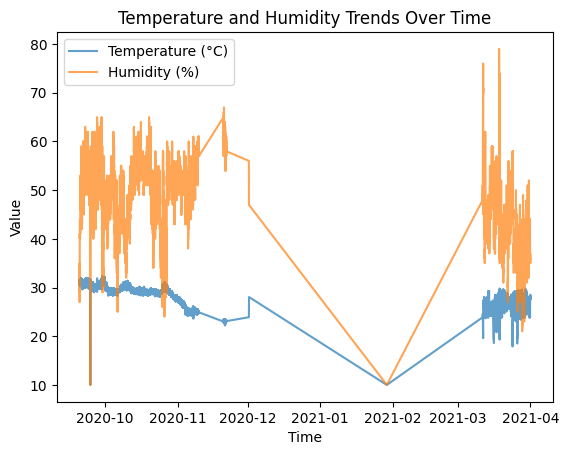

In [10]:
# apply the example in slide 48
import matplotlib.pyplot as plt

# Convert result_time to datetime
df['result_time'] = pd.to_datetime(df['result_time'])

# Plot temperature and humidity over time
plt.plot(df['result_time'], df['temp'], label='Temperature (°C)', alpha=0.7)
plt.plot(df['result_time'], df['humid'], label='Humidity (%)', alpha=0.7)
plt.title("Temperature and Humidity Trends Over Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


## Understanding Data Distributions
#### Objective: 
* Explore the distribution of sensor readings.
* Histogram: Temperature Distribution 


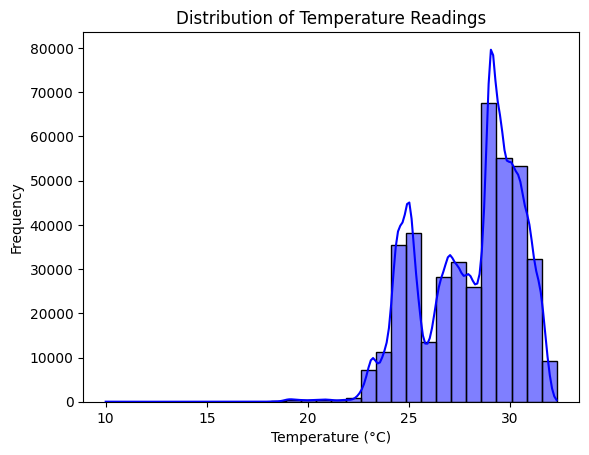

In [13]:
# Apply example in slide 50
import seaborn as sns

# Plot the distribution of temperature
sns.histplot(df['temp'], kde=True, bins=30, color='blue')
plt.title("Distribution of Temperature Readings")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()


## Examining Relationships Between Variable
#### Objective: 
* Visualize correlations between key variables.
* Scatter Plot: Temperature vs. Humidity 


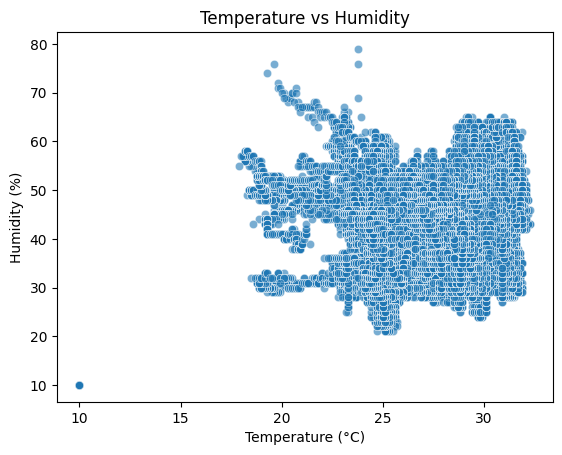

In [14]:
# Apply the example in slide 51
# Scatter plot of temperature vs. humidity
sns.scatterplot(x='temp', y='humid', data=df, alpha=0.6)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()


#### Pair Plot

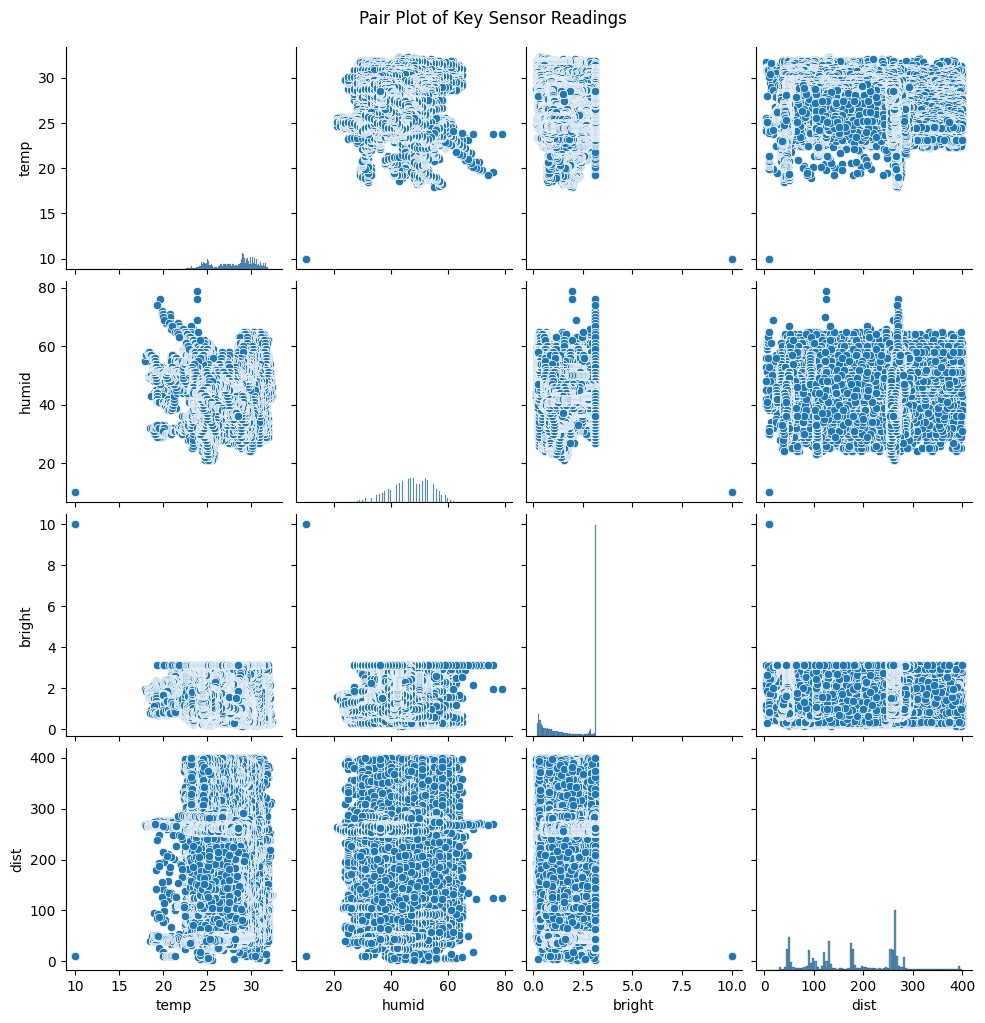

In [15]:
# Apply the example in slide 52
# Pair plot to explore multiple relationships
sns.pairplot(df[['temp', 'humid', 'bright', 'dist']])
plt.suptitle("Pair Plot of Key Sensor Readings", y=1.02)
plt.show()


## Heatmaps for Correlation Analysis
#### Objective: Analyze how variables are correlated


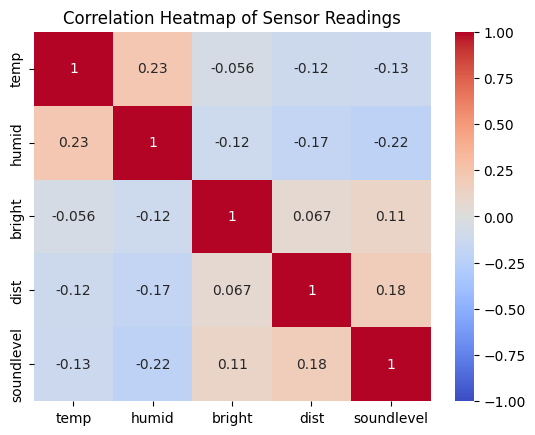

In [16]:
# Apply the example in slide 53

# Compute correlation matrix
correlation_matrix = df[['temp', 'humid', 'bright', 'dist', 'soundlevel']].corr()

# Heatmap of correlations
sns.heatmap(correlation_matrix, annot=True, vmin=-1,  vmax=1, cmap="coolwarm")
plt.title("Correlation Heatmap of Sensor Readings")
plt.show()
